In [1]:
import glob
import os

import scipy

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# Data loading

## Gene sets

In [2]:
genesets_dir = "/Users/willtrim/Documents/reference/msigdb/msigdb_v2025.1.Hs_GMTs/"

genesets_fps = glob.glob(os.path.join(genesets_dir, "*.tsv"))

In [3]:
genesets = {}

for genesets_fp in genesets_fps:
    
    db_name = os.path.basename(genesets_fp).split(".")[0]
    
    db_genesets = pd.read_csv(genesets_fp, sep="\t", index_col=0)
    
    db_genesets.pathways = db_genesets.pathways.str.split(", ").map(set)

    genesets[db_name] = db_genesets

In [4]:
from functools import reduce

all_genesets_genes = set()

for db_name, db_genesets in genesets.items():
    all_genesets_genes |= reduce(lambda a, b: a | b, db_genesets.pathways)

In [5]:
len(all_genesets_genes)

20835

## Gene entrez ids

In [6]:
rlog_fp = "/Users/willtrim/Documents/projs/bedrest/outputs/rlog_counts_star_rsem.csv"

rlog = pd.read_csv(rlog_fp, index_col=0)
rlog.head()

,A1_Post,A2_Post,B1_Post,B2_Post,C1_Post,C2_Post,D1_Post,D2_Post,E1_Post,E2_Post,...,F1_Pre,F2_Pre,G1_Pre,G2_Pre,H1_Pre,H2_Pre,I1_Pre,I2_Pre,J1_Pre,J2_Pre
ENSG00000000003.16,10.441921,10.445695,10.129874,10.407166,10.471710,10.332573,10.475635,10.371279,10.271373,10.478572,...,10.624568,10.406151,10.390147,10.375603,10.477752,10.546246,10.341907,10.286274,10.390158,10.528786
ENSG00000000005.6,8.866141,9.707402,8.760895,9.202013,9.195625,9.546052,9.231500,8.893196,9.588682,9.701247,...,9.570189,9.421571,9.532899,8.976220,9.199024,9.235549,10.564737,9.264435,9.285173,9.000341
ENSG00000000419.14,9.649389,9.530534,9.837392,9.724397,9.756636,9.603278,9.663451,9.706612,9.574476,9.587087,...,9.581840,9.648275,9.629305,9.699160,9.912812,9.681877,9.539867,9.670682,9.580647,9.684913
ENSG00000000457.14,8.870346,8.738457,9.048945,8.681763,9.015666,8.724369,8.910953,8.897573,8.923367,8.787728,...,8.848077,8.845071,8.906610,8.961840,8.824269,8.874319,8.880181,8.854554,8.810754,8.941380
ENSG00000000460.17,6.744174,6.579216,6.661595,6.299408,6.381015,6.585593,6.538086,6.640206,6.525538,6.582556,...,6.550203,6.407576,6.513301,6.511696,6.484146,6.452780,6.741276,6.349335,6.665601,6.655332


In [7]:
gene_ids = rlog.index.to_series().str.split(".", expand=True).iloc[:,0]

In [ ]:
# print(" ".join(gene_ids))

In [8]:
gene_names = pd.read_csv("/Users/willtrim/Documents/projs/bedrest/outputs/gProfiler_hsapiens_31-01-2026_21-57-11.csv", dtype={1: str})
gene_names

,initial_alias,converted_alias,name,description,namespace
0,ENSG00000000003,7105,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
1,ENSG00000000005,64102,TNMD,tenomodulin [Source:HGNC Symbol;Acc:HGNC:17757],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
2,ENSG00000000419,8813,DPM1,dolichyl-phosphate mannosyltransferase subunit...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
3,ENSG00000000457,57147,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;A...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
4,ENSG00000000460,55732,FIRRM,FIGNL1 interacting regulator of recombination ...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
...,...,...,...,...,...
25951,ENSG00000310537,NaN,NaN,NaN,NaN
25952,ENSG00000310539,100887824,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25953,ENSG00000310539,84771,DDX11L2,DEAD/H-box helicase 11 like 2 (pseudogene) [So...,"ARRAYEXPRESS,ENSG"
25954,ENSG00000310560,NaN,NaN,NaN,NaN


In [9]:
gene_names.value_counts("initial_alias")

initial_alias
ENSG00000278233    208
ENSG00000278189    208
ENSG00000275215    208
ENSG00000277739    207
ENSG00000205457      6
                  ... 
ENSG00000001561      1
ENSG00000001617      1
ENSG00000001629      1
ENSG00000001630      1
ENSG00000001631      1
Name: count, Length: 24834, dtype: int64

In [10]:
gene_names_ = gene_names.loc[gene_names.converted_alias.isin(all_genesets_genes),:]

In [11]:
(gene_names_.value_counts("initial_alias") > 1).sum()

np.int64(64)

In [12]:
gene_names_.value_counts("initial_alias")

initial_alias
ENSG00000278233    208
ENSG00000278189    208
ENSG00000275215    208
ENSG00000277739    207
ENSG00000173213      4
                  ... 
ENSG00000292995      1
ENSG00000293137      1
ENSG00000293316      1
ENSG00000293317      1
ENSG00000001036      1
Name: count, Length: 14971, dtype: int64

In [13]:
gene_names_.loc[gene_names_.initial_alias == "ENSG00000173213",:]

,initial_alias,converted_alias,name,description,namespace
11635,ENSG00000173213,124908013,TUBB8B,tubulin beta 8B [Source:HGNC Symbol;Acc:HGNC:2...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
11636,ENSG00000173213,124908015,TUBB8B,tubulin beta 8B [Source:HGNC Symbol;Acc:HGNC:2...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
11637,ENSG00000173213,124908041,TUBB8B,tubulin beta 8B [Source:HGNC Symbol;Acc:HGNC:2...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
11638,ENSG00000173213,260334,TUBB8B,tubulin beta 8B [Source:HGNC Symbol;Acc:HGNC:2...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"


In [14]:
gene_names_ = gene_names_.sort_values(["name", "converted_alias"]).drop_duplicates("initial_alias", keep="first")

In [15]:
gene_names_.set_index("initial_alias", inplace=True)

In [16]:
gene_names_.head()

,converted_alias,name,description,namespace
initial_alias,,,,
ENSG00000277739,124907114,5_8S_rRNA,5.8S ribosomal RNA [Source:RFAM;Acc:RF00002],"ARRAYEXPRESS,ENSG"
ENSG00000121410,1,A1BG,alpha-1-B glycoprotein [Source:HGNC Symbol;Acc...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000175899,2,A2M,alpha-2-macroglobulin [Source:HGNC Symbol;Acc:...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000128274,53947,A4GALT,"alpha 1,4-galactosyltransferase (P1PK blood gr...","ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000094914,8086,AAAS,aladin WD repeat nucleoporin [Source:HGNC Symb...,"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"


In [17]:
gene_names_.value_counts("converted_alias")

converted_alias
100037417    2
9782         2
8916         2
883          2
8622         2
            ..
9969         1
997          1
9972         1
9973         1
1            1
Name: count, Length: 14931, dtype: int64

In [18]:
gene_names_.loc[gene_names_.converted_alias == "9782",:]

,converted_alias,name,description,namespace
initial_alias,,,,
ENSG00000015479,9782,MATR3,matrin 3 [Source:HGNC Symbol;Acc:HGNC:6912],"ARRAYEXPRESS,ENSG,HPA,HPA_ACC"
ENSG00000280987,9782,MATR3,matrin 3 [Source:NCBI gene (formerly Entrezgen...,"ARRAYEXPRESS,ENSG"


In [19]:
gene_names__ = gene_names_.drop_duplicates("converted_alias", keep=False)

In [20]:
gene_names__.set_index("initial_alias", inplace=True)

KeyError: "None of ['initial_alias'] are in the columns"

In [21]:
gene_names.loc[gene_names.initial_alias == "ENSG00000143627",:]

,initial_alias,converted_alias,name,description,namespace


In [22]:
t = cors["insulin_art"]["pre"]
t.loc[t.ensembl_gene_id == "ENSG00000143627", :]

NameError: name 'cors' is not defined

## Correlations

In [23]:
cors_dir = "/Users/willtrim/Documents/projs/bedrest/outputs/cors2/"

cors_fps = glob.glob(os.path.join(cors_dir, "*_*.csv"))

cors = {}

cols = ["converted_alias", "name", "description"]

for cors_fp in cors_fps:
    tmp, phen = os.path.basename(cors_fp).split(".")[0].split("_", maxsplit=1)

    tmp_phen_cors = pd.read_csv(cors_fp)

    tmp_phen_cors["ensembl_gene_id"] = tmp_phen_cors.gene.str.split(".", expand=True).iloc[:,0]
    
    tmp_phen_cors[cols] = None
    idx = tmp_phen_cors.ensembl_gene_id.isin(gene_names__.index)
    tmp_phen_cors.loc[idx, cols] = gene_names__.loc[tmp_phen_cors.loc[idx, "ensembl_gene_id"], cols].values
    
    if phen in cors:
        cors[phen][tmp] = tmp_phen_cors
    else:
        cors[phen] = {tmp: tmp_phen_cors} 

    # break

# Heatmaps

Gene sets:

1. Insulin signaling pathway, glucose transport, AKT, PTPN1
3. TAG storage/Lipolysis, FOXO, PPARg, G3P synthesis
4. PPP, NADPH, ROS
5. TCA, glycolysis
7. Mitochondria and b-oxidation
8. adipokines
9. peroxisomes and fatty acid oxidation
10. ribosomes and mTOR?

In [24]:
gene_id = "converted_alias"

gene_rs = {
    f"{pheno_name}_{tmp}": tmp_pheno_cors.dropna(subset=gene_id).set_index(gene_id)["r"]
    for pheno_name, pheno_cors in cors.items()
    for tmp, tmp_pheno_cors in pheno_cors.items()}

gene_pvals = {
    f"{pheno_name}_{tmp}": tmp_pheno_cors.dropna(subset=gene_id).set_index(gene_id)["pvalue"]
    for pheno_name, pheno_cors in cors.items()
    for tmp, tmp_pheno_cors in pheno_cors.items()}

gene_rs_df = pd.concat(gene_rs, axis=1, verify_integrity=True)
gene_pvals_df = pd.concat(gene_pvals, axis=1, verify_integrity=True)

In [25]:
gene_rs_df.head()

,insulin_art_pre,insulin_art_post,FFA_pre,FFA_post,fat_ox_post,fat_ox_pre,insulin_ven_post,insulin_ven_pre,glucose_art_post,glucose_art_pre,TAG_post,TAG_pre,glucose_ven_pre,glucose_ven_post,cho_ox_post,cho_ox_pre,glucose_diposal_post,glucose_diposal_pre
converted_alias,,,,,,,,,,,,,,,,,,
7105,-0.201504,0.019298,0.240602,0.365950,0.319298,0.114286,0.376481,0.320124,0.121159,0.199624,-0.101844,0.228163,0.182712,0.241865,-0.649510,-0.220588,0.357895,-0.248120
64102,0.204511,0.410526,0.013534,0.066696,0.121053,0.162406,0.413339,0.122311,0.331870,0.326178,0.556629,0.548193,-0.009815,0.206685,-0.098039,-0.093137,-0.114035,-0.395489
8813,-0.078195,-0.314035,0.010526,0.242212,0.163158,-0.362406,0.157086,0.370709,-0.205443,-0.237289,-0.327480,-0.000753,-0.302758,-0.068602,-0.301471,0.232843,0.138596,0.105263
57147,-0.138398,-0.407196,-0.197819,0.074627,0.064941,-0.197067,0.141352,0.202418,-0.303909,-0.002261,-0.151076,-0.225612,0.358386,0.018478,-0.240343,-0.077253,-0.189557,-0.285070
55732,0.020308,-0.052655,-0.113577,-0.167691,0.463361,-0.097781,-0.183055,0.122357,-0.288098,0.192917,0.172156,0.147646,0.284368,-0.384515,-0.117719,-0.185163,0.101799,-0.270779


In [26]:
gene_pvals_df.head()

,insulin_art_pre,insulin_art_post,FFA_pre,FFA_post,fat_ox_post,fat_ox_pre,insulin_ven_post,insulin_ven_pre,glucose_art_post,glucose_art_pre,TAG_post,TAG_pre,glucose_ven_pre,glucose_ven_post,cho_ox_post,cho_ox_pre,glucose_diposal_post,glucose_diposal_pre
converted_alias,,,,,,,,,,,,,,,,,,
7105,0.394261,0.937498,0.306861,0.123349,0.182696,0.631392,0.112120,0.168826,0.621240,0.398780,0.678237,0.333285,0.440692,0.318469,0.004776,0.394889,0.132460,0.291523
64102,0.387090,0.080832,0.954840,0.786171,0.621549,0.493913,0.078571,0.607456,0.165108,0.160462,0.013312,0.012332,0.967241,0.395893,0.708151,0.722186,0.642044,0.084352
8813,0.743149,0.190420,0.964869,0.317756,0.504516,0.116345,0.520714,0.107605,0.398800,0.313772,0.171112,0.997486,0.194459,0.780202,0.239624,0.368460,0.571491,0.658728
57147,0.560639,0.083570,0.403145,0.761409,0.791679,0.404972,0.563790,0.392072,0.205888,0.992453,0.536985,0.338865,0.120754,0.940150,0.352784,0.768222,0.437010,0.223126
55732,0.932276,0.830483,0.633524,0.492582,0.045711,0.681719,0.453181,0.607320,0.231655,0.415133,0.480962,0.534470,0.224317,0.104060,0.652733,0.476785,0.678371,0.248206


In [157]:
output_dir = "/Users/willtrim/Documents/projs/bedrest/outputs/cors2/"
gene_rs_df.to_csv(os.path.join(output_dir, "rs.csv"))
gene_pvals_df.to_csv(os.path.join(output_dir, "pvals.csv"))

## KEGG genesets

Gene sets:

1. Insulin signaling pathway, glucose transport, AKT, PTPN1
3. TAG storage/Lipolysis, FOXO, PPARg, G3P synthesis
4. PPP, NADPH, ROS
5. TCA, glycolysis
7. Mitochondria and b-oxidation
8. adipokines
9. peroxisomes and fatty acid oxidation
10. ribosomes and mTOR?

In [29]:
db = "KEGG"

In [ ]:
# print("\n".join(genesets[db].index))

### Insulin signaling pathway, glucose transport, AKT, PTPN1

In [ ]:
Inositol phosphate metabolism
Glycosylphosphatidylinositol (GPI)-anchor biosynthesis
Glycerophospholipid metabolism
Phosphatidylinositol signaling system
Phospholipase D signaling pathway

Insulin signaling pathway
PI3K-Akt signaling pathway

Type II diabetes mellitus
Insulin resistance
Non-alcoholic fatty liver disease


#### Insulin signaling pathway

In [41]:
pathway = "Insulin signaling pathway"
pathway_genes = genesets[db].loc[pathway, "pathways"]
len(pathway_genes)

138

In [45]:
pathway_rs = gene_rs_df.loc[gene_rs_df.index.isin(pathway_genes),:]
pathway_pvals = gene_pvals_df.loc[gene_rs_df.index.isin(pathway_genes),:]

assert (pathway_rs.index == pathway_pvals.index).all()

In [55]:
pathway_gene_names = gene_names__.loc[pathway_rs.index, "name"]

In [67]:
pval_threshold = 0.05

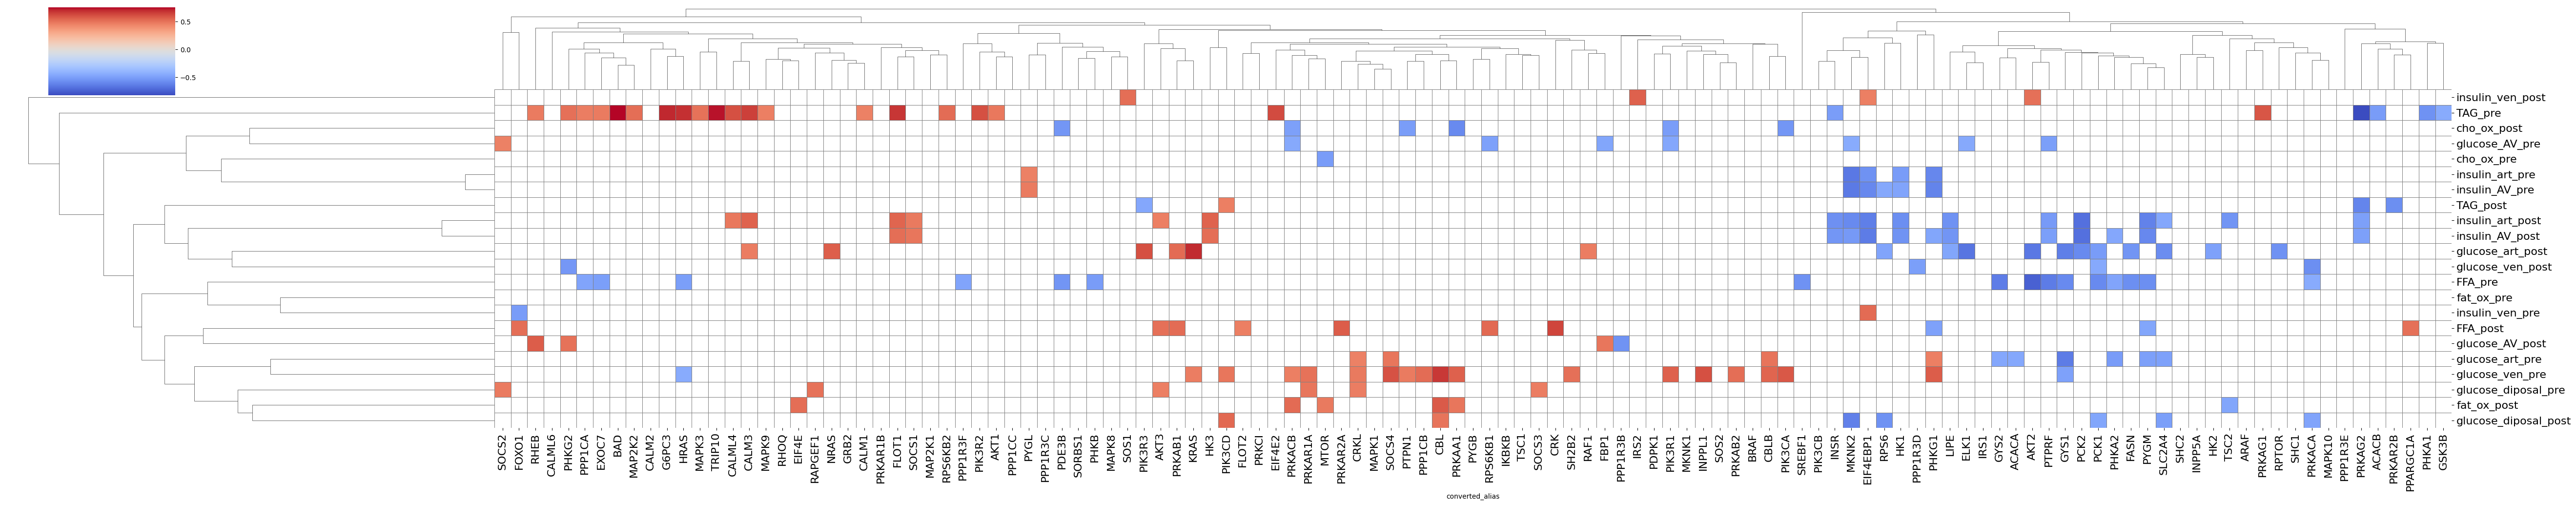

In [77]:
# fix, ax = plt.subplots(figsize=(52, 8))

mask = pathway_pvals.T > pval_threshold

g = sns.clustermap(pathway_rs.T, cmap="coolwarm", xticklabels=pathway_gene_names, mask=mask, linewidths=.5, linecolor='grey', figsize=(52, 10))
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)


#### Insulin resistance

In [84]:
pathway = "Insulin resistance"
pathway_genes = genesets[db].loc[pathway, "pathways"]
len(pathway_genes)

109

In [85]:
pathway_rs = gene_rs_df.loc[gene_rs_df.index.isin(pathway_genes),:]
pathway_pvals = gene_pvals_df.loc[gene_rs_df.index.isin(pathway_genes),:]

assert (pathway_rs.index == pathway_pvals.index).all()

In [86]:
pathway_gene_names = gene_names__.loc[pathway_rs.index, "name"]

In [87]:
pval_threshold = 0.05

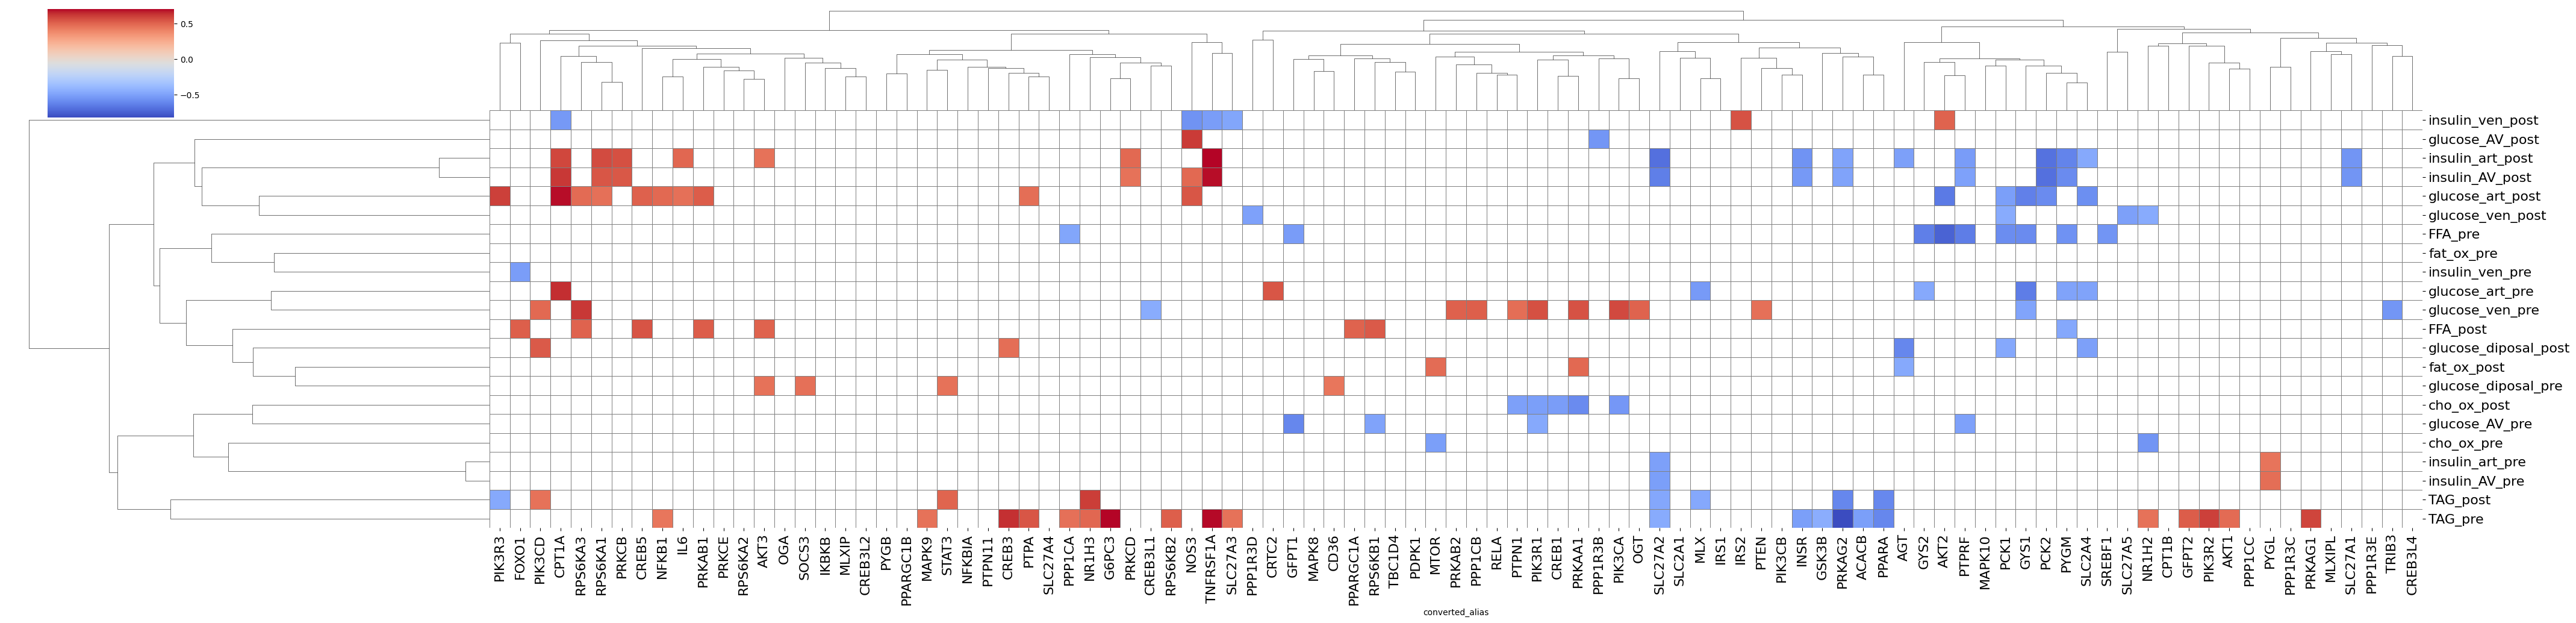

In [89]:
# fix, ax = plt.subplots(figsize=(52, 8))

mask = pathway_pvals.T > pval_threshold

g = sns.clustermap(pathway_rs.T, cmap="coolwarm", xticklabels=pathway_gene_names, mask=mask, linewidths=.5, linecolor='grey', figsize=(42, 10))
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)


#### PI3K-Akt signaling pathway

In [78]:
pathway = "PI3K-Akt signaling pathway"
pathway_genes = genesets[db].loc[pathway, "pathways"]
len(pathway_genes)

362

In [79]:
pathway_rs = gene_rs_df.loc[gene_rs_df.index.isin(pathway_genes),:]
pathway_pvals = gene_pvals_df.loc[gene_rs_df.index.isin(pathway_genes),:]

assert (pathway_rs.index == pathway_pvals.index).all()

In [80]:
pathway_gene_names = gene_names__.loc[pathway_rs.index, "name"]

In [81]:
pval_threshold = 0.05

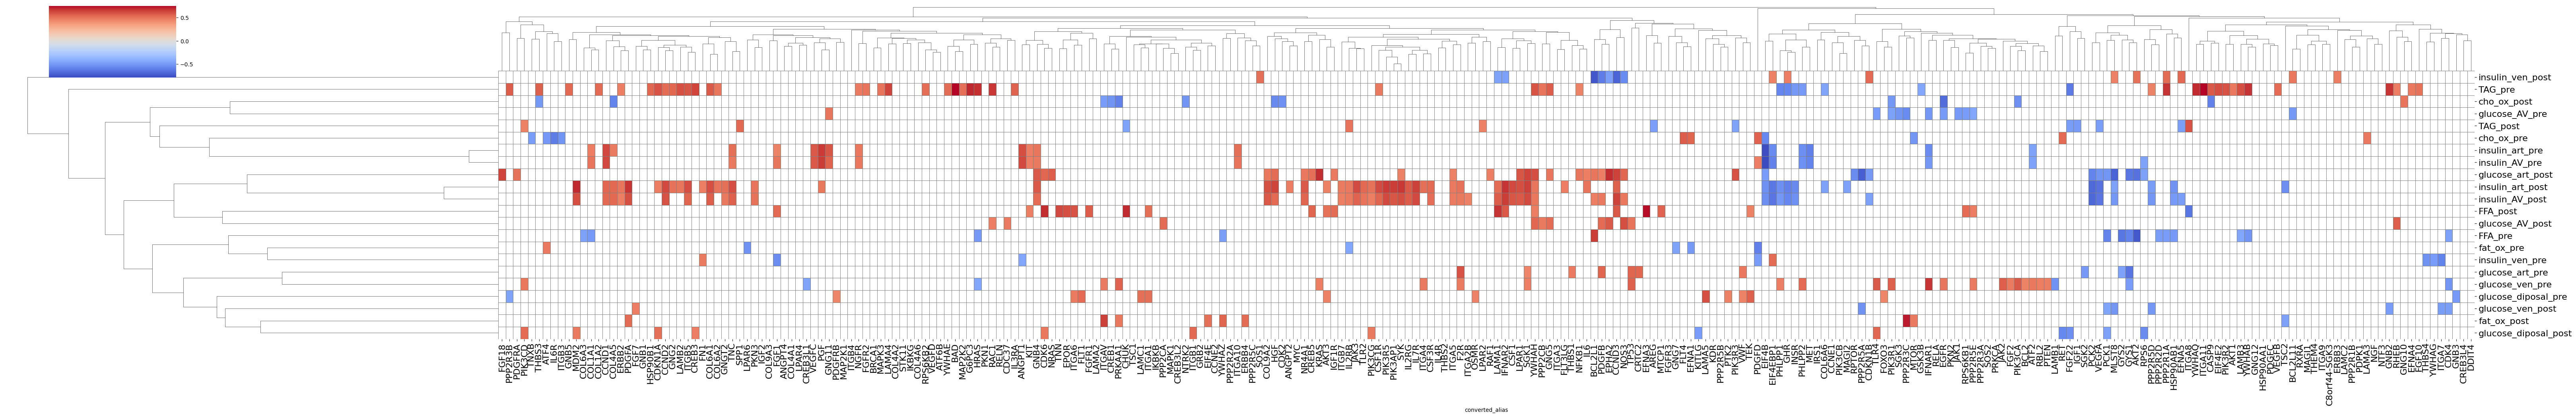

In [83]:
# fix, ax = plt.subplots(figsize=(52, 8))

mask = pathway_pvals.T > pval_threshold

g = sns.clustermap(pathway_rs.T, cmap="coolwarm", xticklabels=pathway_gene_names, mask=mask, linewidths=.5, linecolor='grey', figsize=(64, 10))
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)


### TAG storage/Lipolysis, FOXO, PPARg, G3P synthesis

In [ ]:
Glycerolipid metabolism
ABC transporters
PPAR signaling pathway
FoxO signaling pathway
Glucagon signaling pathway
Regulation of lipolysis in adipocytes

Lipoic acid metabolism

Fat digestion and absorption
Cholesterol metabolism
Lipid and atherosclerosis

#### Regulation of lipolysis in adipocytes

In [96]:
pathway = "Regulation of lipolysis in adipocytes"
pathway_genes = genesets[db].loc[pathway, "pathways"]
len(pathway_genes)

59

In [97]:
pathway_rs = gene_rs_df.loc[gene_rs_df.index.isin(pathway_genes),:]
pathway_pvals = gene_pvals_df.loc[gene_rs_df.index.isin(pathway_genes),:]

assert (pathway_rs.index == pathway_pvals.index).all()

In [98]:
pathway_gene_names = gene_names__.loc[pathway_rs.index, "name"]

In [99]:
pval_threshold = 0.05

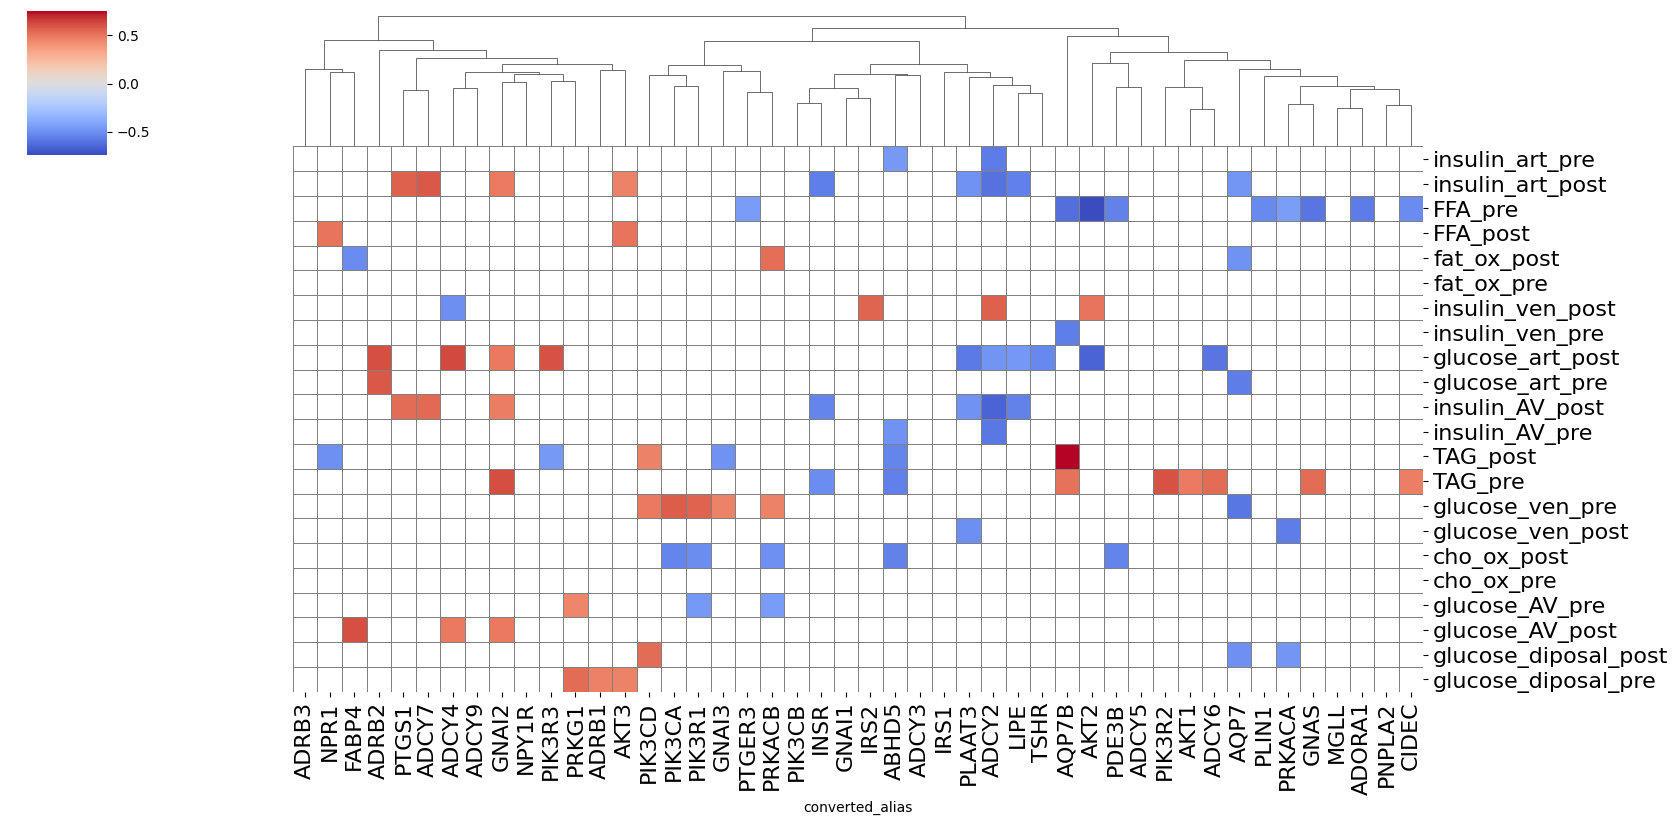

In [104]:
# fix, ax = plt.subplots(figsize=(52, 8))

mask = pathway_pvals.T > pval_threshold

g = sns.clustermap(pathway_rs.T, cmap="coolwarm", xticklabels=pathway_gene_names, mask=mask, linewidths=.5, linecolor='grey', figsize=(16, 8), row_cluster=False)
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)


#### PPAR signaling pathway

In [90]:
pathway = "PPAR signaling pathway"
pathway_genes = genesets[db].loc[pathway, "pathways"]
len(pathway_genes)

76

In [91]:
pathway_rs = gene_rs_df.loc[gene_rs_df.index.isin(pathway_genes),:]
pathway_pvals = gene_pvals_df.loc[gene_rs_df.index.isin(pathway_genes),:]

assert (pathway_rs.index == pathway_pvals.index).all()

In [92]:
pathway_gene_names = gene_names__.loc[pathway_rs.index, "name"]

In [93]:
pval_threshold = 0.05

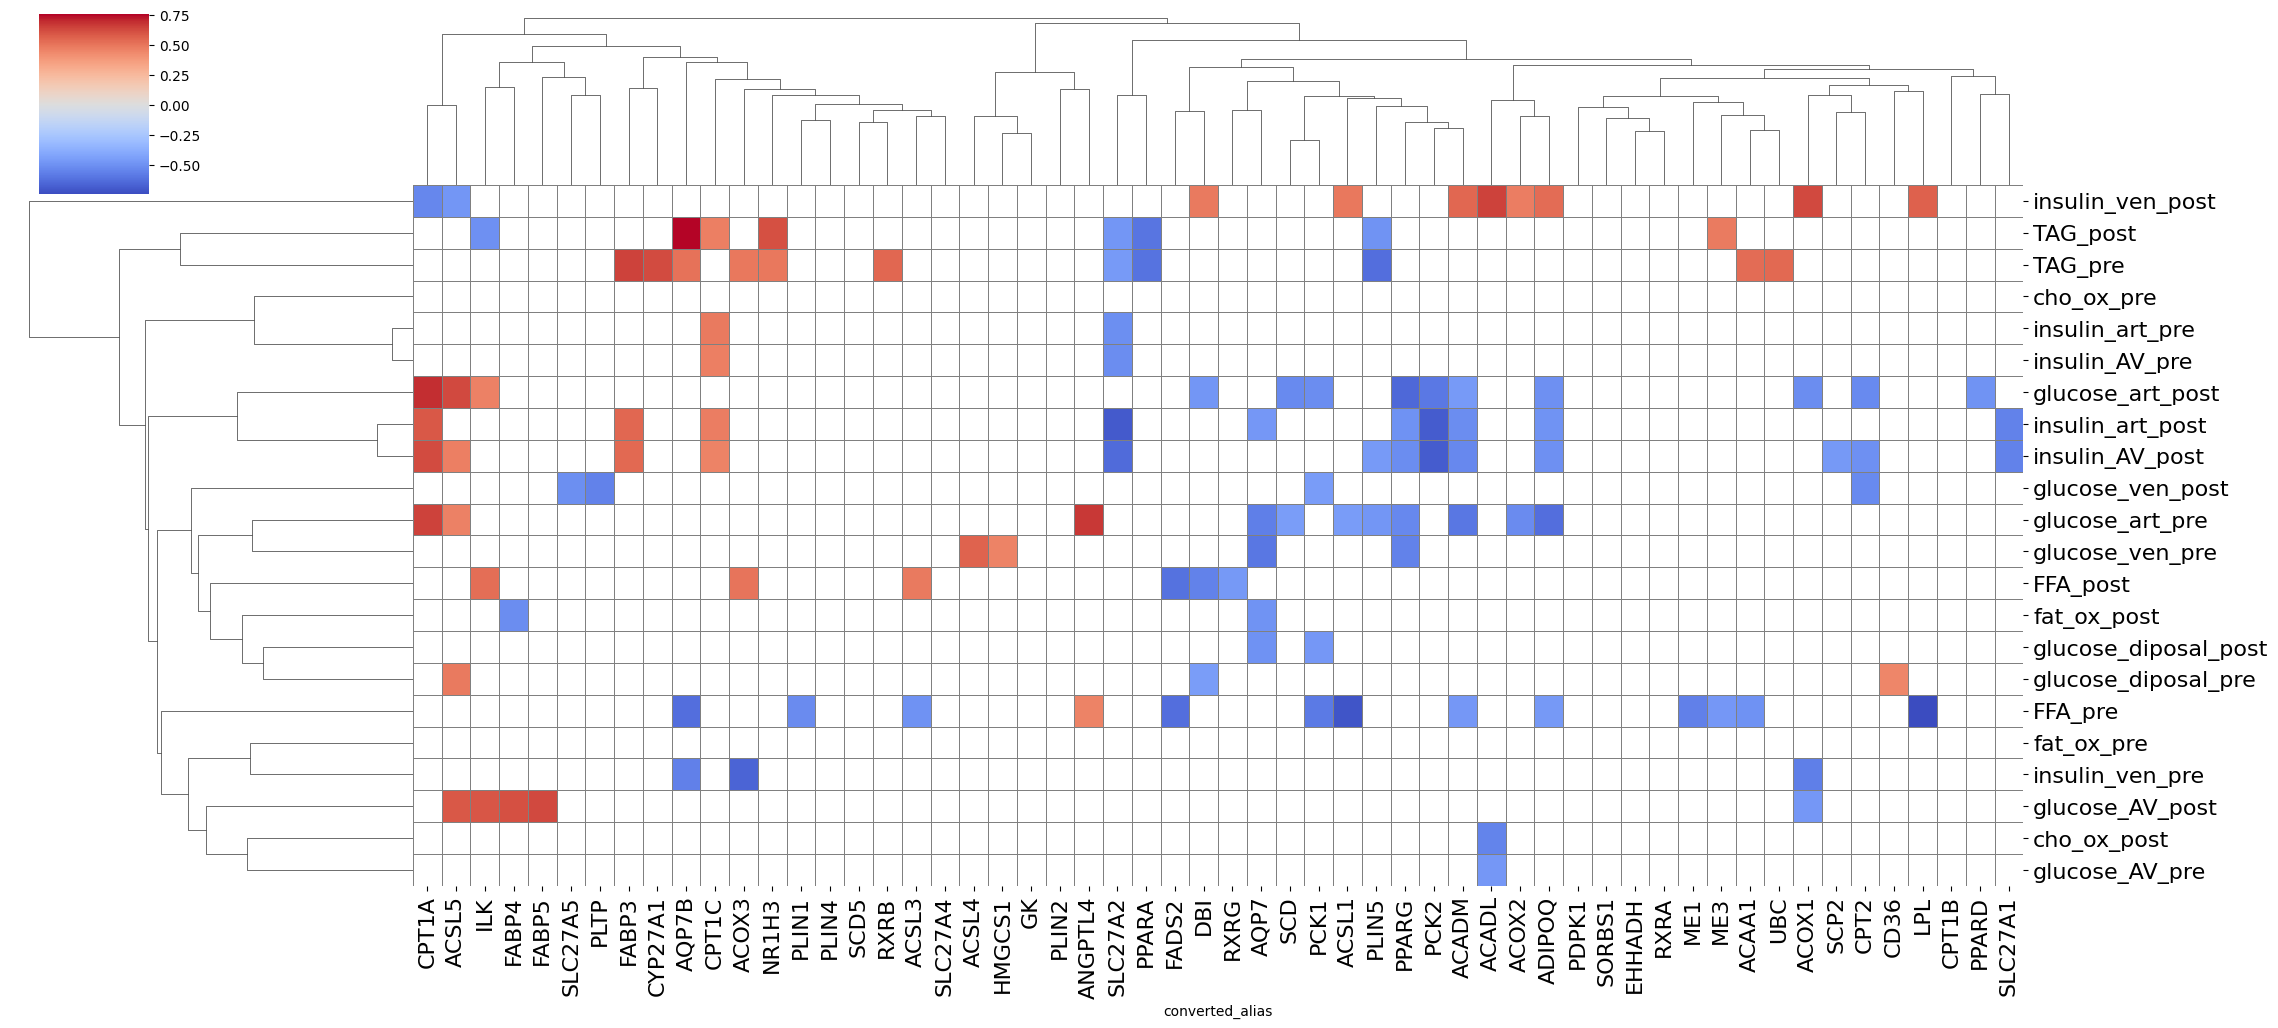

In [95]:
# fix, ax = plt.subplots(figsize=(52, 8))

mask = pathway_pvals.T > pval_threshold

g = sns.clustermap(pathway_rs.T, cmap="coolwarm", xticklabels=pathway_gene_names, mask=mask, linewidths=.5, linecolor='grey', figsize=(22, 10))
_ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
_ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)


### PPP, NADPH, ROS

In [ ]:
Pentose phosphate pathway
Glutathione metabolism


AGE-RAGE signaling pathway in diabetic complications


### TCA, glycolysis

In [ ]:
Glycolysis / Gluconeogenesis
Citrate cycle (TCA cycle)
Pyruvate metabolism
2-Oxocarboxylic acid metabolism
Carbohydrate digestion and absorption

### Mitochondria, b-oxidation

In [ ]:
Oxidative phosphorylation


Fatty acid biosynthesis
Fatty acid elongation
Fatty acid degradation
Fatty acid metabolism


### Adipokines

In [ ]:
Adipocytokine signaling pathway
Apelin signaling pathway

### Peroxisomes

In [ ]:
Glyoxylate and dicarboxylate metabolism
Peroxisome


### Ribosomes and mTOR

In [ ]:
Ribosome biogenesis in eukaryotes
Ribosome

### Misc

In [ ]:
Spliceosome
Proteasome
Protein export
Cell cycle
Ubiquitin mediated proteolysis
Protein processing in endoplasmic reticulum
Lysosome
Endocytosis
Phagosome
Apoptosis
Thermogenesis
Protein digestion and absorption

MAPK signaling pathway
ErbB signaling pathway
Ras signaling pathway
Rap1 signaling pathway
cGMP-PKG signaling pathway
cAMP signaling pathway
NF-kappa B signaling pathway
mTOR signaling pathway
AMPK signaling pathway
Wnt signaling pathway
Notch signaling pathway
Hedgehog signaling pathway
TGF-beta signaling pathway
Hippo signaling pathway
JAK-STAT signaling pathway
TNF signaling pathway
Toll-like receptor signaling pathway


# Output for pathview

In [27]:
gene_id = "ensembl_gene_id"

gene_rs = {
    f"{pheno_name}_{tmp}": tmp_pheno_cors.dropna(subset=gene_id).set_index(gene_id)["r"]
    for pheno_name, pheno_cors in cors.items()
    for tmp, tmp_pheno_cors in pheno_cors.items()}

gene_pvals = {
    f"{pheno_name}_{tmp}": tmp_pheno_cors.dropna(subset=gene_id).set_index(gene_id)["pvalue"]
    for pheno_name, pheno_cors in cors.items()
    for tmp, tmp_pheno_cors in pheno_cors.items()}

gene_rs_df = pd.concat(gene_rs, axis=1, verify_integrity=True)
gene_pvals_df = pd.concat(gene_pvals, axis=1, verify_integrity=True)

In [28]:
gene_rs_df.head()

,insulin_art_pre,insulin_art_post,FFA_pre,FFA_post,fat_ox_post,fat_ox_pre,insulin_ven_post,insulin_ven_pre,glucose_art_post,glucose_art_pre,TAG_post,TAG_pre,glucose_ven_pre,glucose_ven_post,cho_ox_post,cho_ox_pre,glucose_diposal_post,glucose_diposal_pre
ensembl_gene_id,,,,,,,,,,,,,,,,,,
ENSG00000000003,-0.201504,0.019298,0.240602,0.365950,0.319298,0.114286,0.376481,0.320124,0.121159,0.199624,-0.101844,0.228163,0.182712,0.241865,-0.649510,-0.220588,0.357895,-0.248120
ENSG00000000005,0.204511,0.410526,0.013534,0.066696,0.121053,0.162406,0.413339,0.122311,0.331870,0.326178,0.556629,0.548193,-0.009815,0.206685,-0.098039,-0.093137,-0.114035,-0.395489
ENSG00000000419,-0.078195,-0.314035,0.010526,0.242212,0.163158,-0.362406,0.157086,0.370709,-0.205443,-0.237289,-0.327480,-0.000753,-0.302758,-0.068602,-0.301471,0.232843,0.138596,0.105263
ENSG00000000457,-0.138398,-0.407196,-0.197819,0.074627,0.064941,-0.197067,0.141352,0.202418,-0.303909,-0.002261,-0.151076,-0.225612,0.358386,0.018478,-0.240343,-0.077253,-0.189557,-0.285070
ENSG00000000460,0.020308,-0.052655,-0.113577,-0.167691,0.463361,-0.097781,-0.183055,0.122357,-0.288098,0.192917,0.172156,0.147646,0.284368,-0.384515,-0.117719,-0.185163,0.101799,-0.270779


In [29]:
gene_pvals_df.head()

,insulin_art_pre,insulin_art_post,FFA_pre,FFA_post,fat_ox_post,fat_ox_pre,insulin_ven_post,insulin_ven_pre,glucose_art_post,glucose_art_pre,TAG_post,TAG_pre,glucose_ven_pre,glucose_ven_post,cho_ox_post,cho_ox_pre,glucose_diposal_post,glucose_diposal_pre
ensembl_gene_id,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.394261,0.937498,0.306861,0.123349,0.182696,0.631392,0.112120,0.168826,0.621240,0.398780,0.678237,0.333285,0.440692,0.318469,0.004776,0.394889,0.132460,0.291523
ENSG00000000005,0.387090,0.080832,0.954840,0.786171,0.621549,0.493913,0.078571,0.607456,0.165108,0.160462,0.013312,0.012332,0.967241,0.395893,0.708151,0.722186,0.642044,0.084352
ENSG00000000419,0.743149,0.190420,0.964869,0.317756,0.504516,0.116345,0.520714,0.107605,0.398800,0.313772,0.171112,0.997486,0.194459,0.780202,0.239624,0.368460,0.571491,0.658728
ENSG00000000457,0.560639,0.083570,0.403145,0.761409,0.791679,0.404972,0.563790,0.392072,0.205888,0.992453,0.536985,0.338865,0.120754,0.940150,0.352784,0.768222,0.437010,0.223126
ENSG00000000460,0.932276,0.830483,0.633524,0.492582,0.045711,0.681719,0.453181,0.607320,0.231655,0.415133,0.480962,0.534470,0.224317,0.104060,0.652733,0.476785,0.678371,0.248206


In [30]:
output_dir = "/Users/willtrim/Documents/projs/bedrest/outputs/cors2/"
gene_rs_df.to_csv(os.path.join(output_dir, "rs.csv"))
gene_pvals_df.to_csv(os.path.join(output_dir, "pvals.csv"))